In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import sklearn
import scipy

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report,accuracy_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from pylab import rcParams
rcParams['figure.figsize']=14,8
RANDOM_SEED=42
LABELS=["Normal","Fraud"]


In [25]:
# The original cell LYzs09WlKIBk was for file upload.
# The following code addresses the user's query about 'fraud.thal.describe()' output.
# Please move this code to the cell where 'fraud' and 'normal' are defined (e.g., cell paL6flJbNTTb)
# to correct the data filtering.

fraud=data[data['target']==1]
normal=data[data['target']==0]
print("Shape of fraud data:", fraud.shape)
print("Shape of normal data:", normal.shape)

print("\nDescription of 'thal' for fraud cases:")
print(fraud.thal.describe())

print("\nDescription of 'thal' for normal cases:")
print(normal.thal.describe())

Shape of fraud data: (165, 14)
Shape of normal data: (138, 14)

Description of 'thal' for fraud cases:
count    165.000000
mean       2.121212
std        0.465752
min        0.000000
25%        2.000000
50%        2.000000
75%        2.000000
max        3.000000
Name: thal, dtype: float64

Description of 'thal' for normal cases:
count    138.000000
mean       2.543478
std        0.684762
min        0.000000
25%        2.000000
50%        3.000000
75%        3.000000
max        3.000000
Name: thal, dtype: float64


In [8]:
data=pd.read_csv('dataset.csv',sep=',')
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [10]:
data.isnull().values.any()

np.False_

/tmp/ipykernel_2169/3387483051.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes=pd.value_counts(data['thalach'],sort=True)


Text(0, 0.5, 'Frequency')

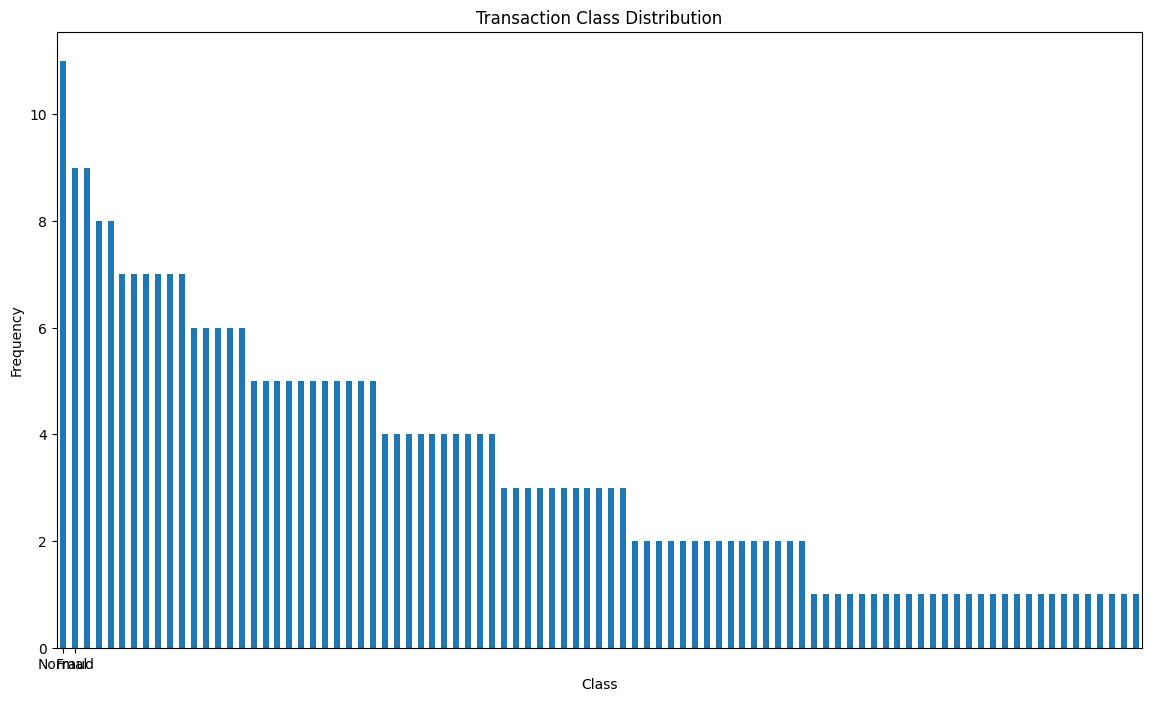

In [14]:
count_classes=pd.value_counts(data['thalach'],sort=True)
count_classes.plot(kind='bar',rot=0)
plt.title("Transaction Class Distribution")
plt.xticks(range(2),LABELS)
plt.xlabel("Class")
plt.ylabel("Frequency")


In [26]:
fraud = data[data['target'] == 1]
normal = data[data['target'] == 0]
print("Shape of fraud data:", fraud.shape)
print("Shape of normal data:", normal.shape)

Shape of fraud data: (165, 14)
Shape of normal data: (138, 14)


In [27]:
fraud.thal.describe()

,thal
count,165.000000
mean,2.121212
std,0.465752
min,0.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,3.000000


In [28]:
normal.thal.describe()

,thal
count,138.000000
mean,2.543478
std,0.684762
min,0.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,3.000000


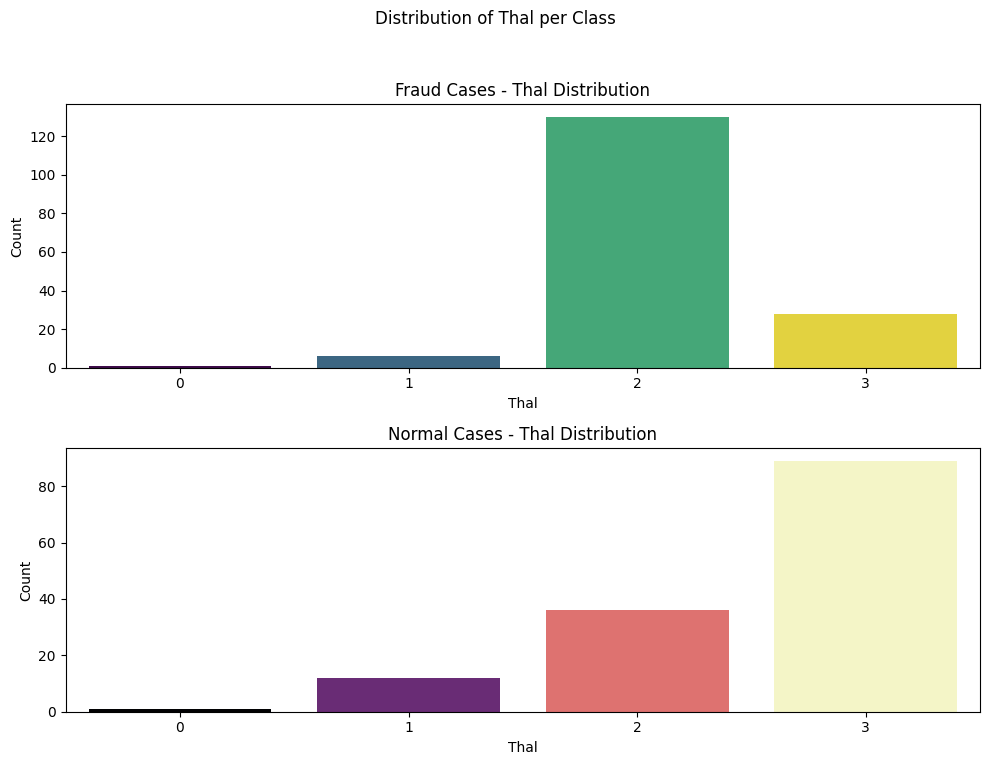

In [33]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=False, figsize=(10, 8))
f.suptitle('Distribution of Thal per Class')


f_thal_counts = fraud['thal'].value_counts().sort_index()
sns.barplot(x=f_thal_counts.index, y=f_thal_counts.values, ax=ax1, palette='viridis', hue=f_thal_counts.index, legend=False)
ax1.set_title('Fraud Cases - Thal Distribution')
ax1.set_xlabel('Thal')
ax1.set_ylabel('Count')
ax1.set_xticks(f_thal_counts.index)

# Bar plot for Normal cases
n_thal_counts = normal['thal'].value_counts().sort_index()
sns.barplot(x=n_thal_counts.index, y=n_thal_counts.values, ax=ax2, palette='magma', hue=n_thal_counts.index, legend=False)
ax2.set_title('Normal Cases - Thal Distribution')
ax2.set_xlabel('Thal')
ax2.set_ylabel('Count')
ax2.set_xticks(n_thal_counts.index)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

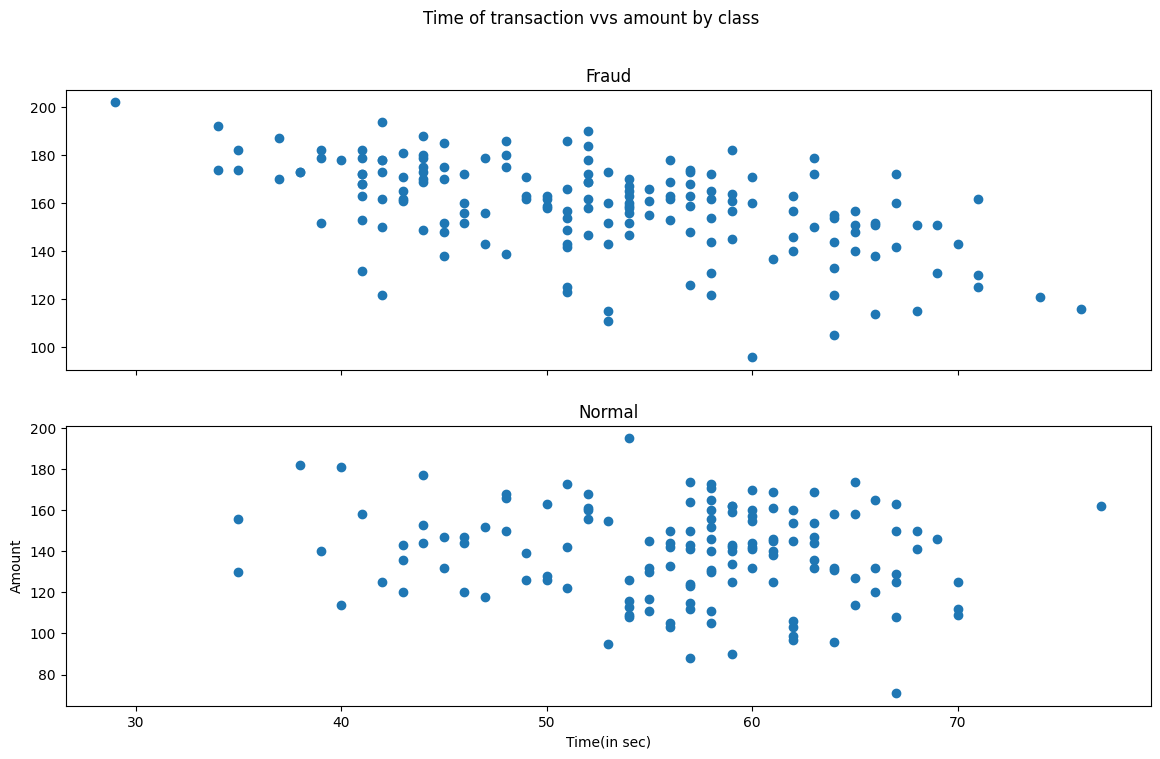

In [36]:
f,(ax1,ax2)=plt.subplots(2,1,sharex=True)
f.suptitle('Time of transaction vvs amount by class')
ax1.scatter(fraud.age,fraud.thalach)
ax1.set_title('Fraud')
ax2.scatter(normal.age,normal.thalach)
ax2.set_title('Normal')
plt.xlabel('Time(in sec)')
plt.ylabel('Amount')
plt.show()

In [38]:
data=data.sample(frac=0.1,random_state=1)
data.shape

(30, 14)

In [40]:
Fraud = data[data['target'] == 1]
Valid = data[data['target'] == 0]


if len(Valid) == 0:
    outlier_fraction = 0
    print("Warning: No 'Valid' cases (target=0) found in the sampled data. Setting outlier_fraction to 0.")
else:
    outlier_fraction = len(Fraud) / float(len(Valid))

print(outlier_fraction)
print('Fraud Cases: {}'.format(len(Fraud)))
print('Valid Cases: {}'.format(len(Valid)))

0.875
Fraud Cases: 14
Valid Cases: 16


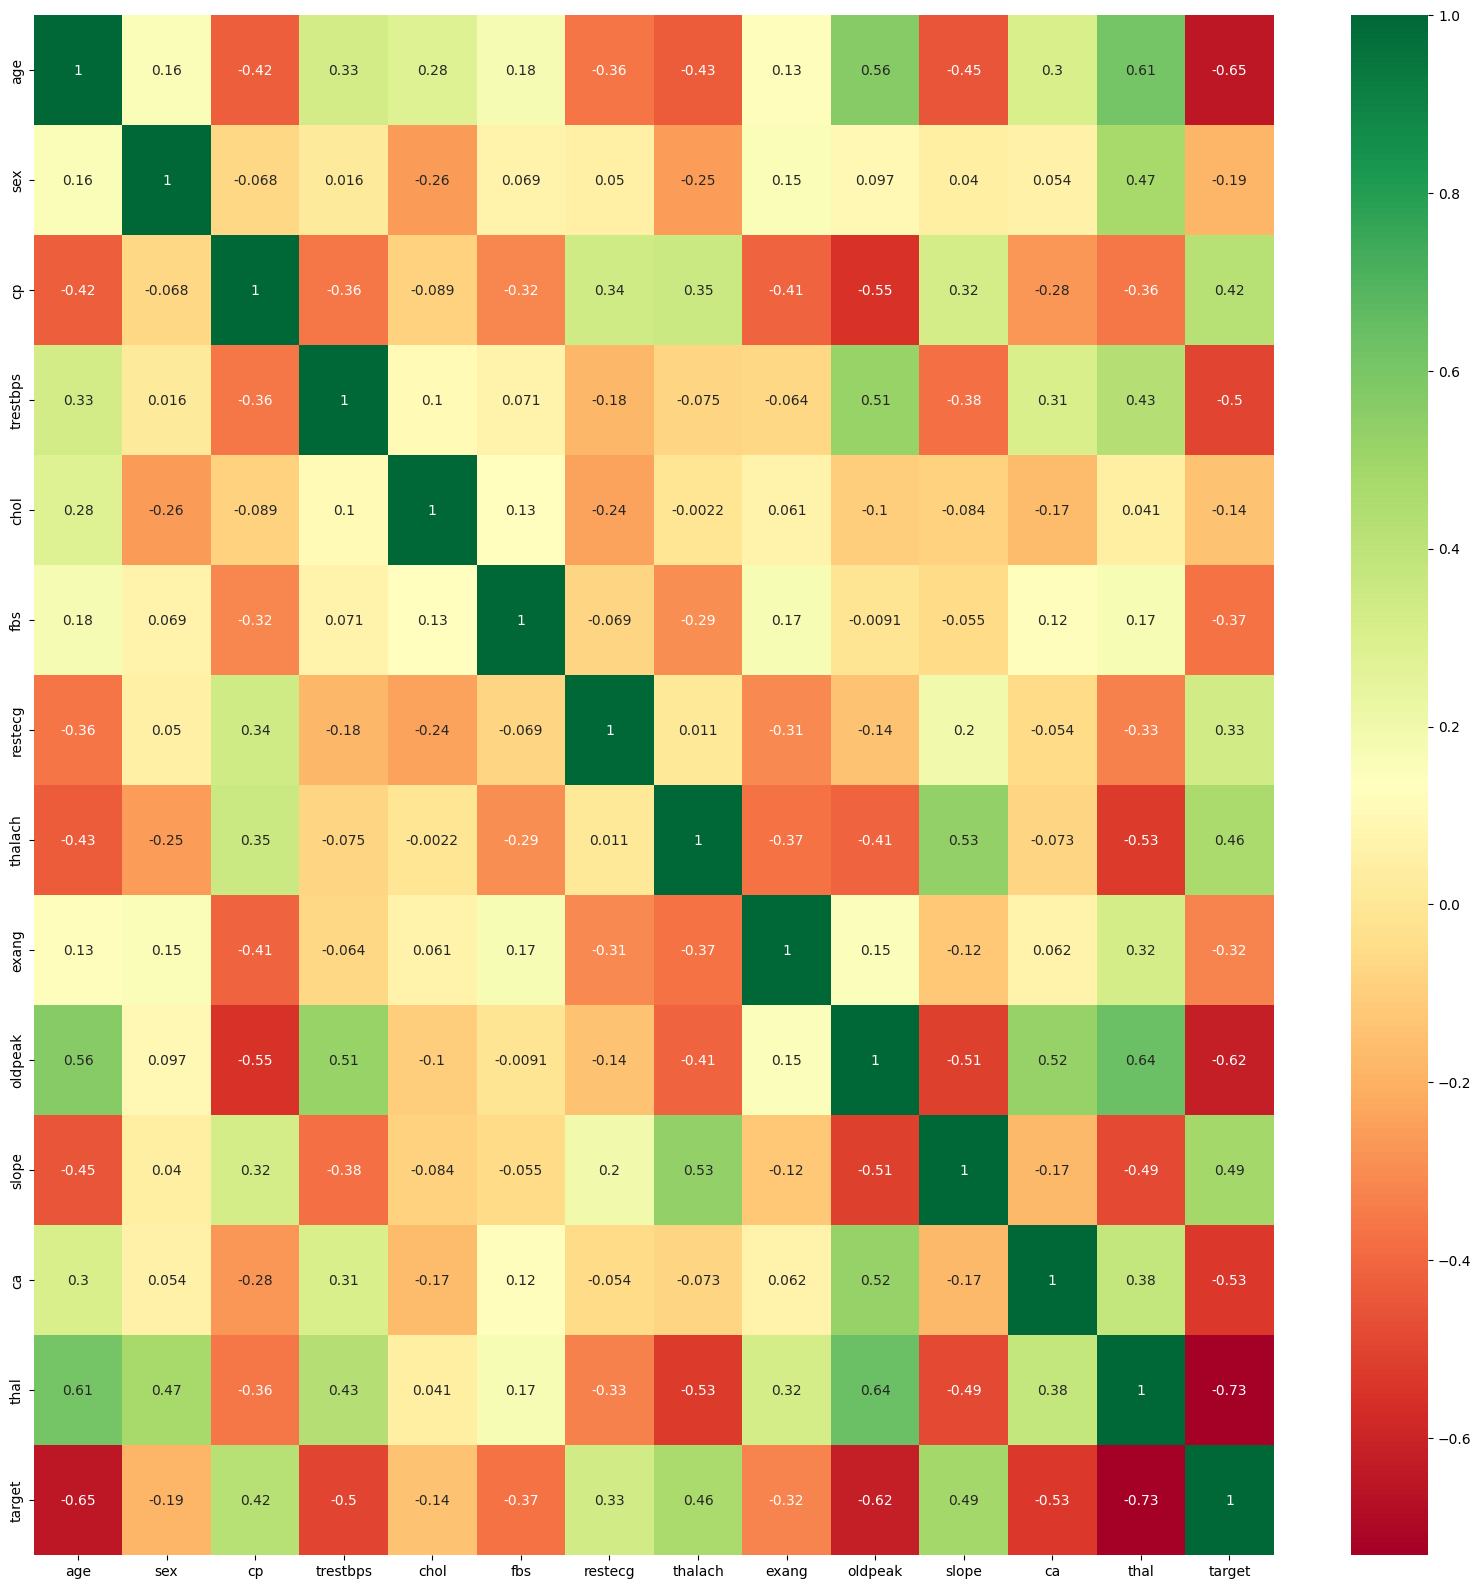

In [41]:
corrmat=data.corr()
top_corr_features=corrmat.index
plt.figure(figsize=(20,20))
g=sns.heatmap(data[top_corr_features].corr(),annot=True,cmap="RdYlGn")

In [47]:
columns_for_features = data.columns.tolist()
columns_for_features = [c for c in columns_for_features if c not in ["target"]]
state = np.random.RandomState(42)
X = data[columns_for_features]
Y = data[target_column_name]
X_outliers=state.uniform(low=0,high=1,size=(X.shape[0],X.shape[1]))
print(X.shape)
print(Y.shape)

(30, 13)
(30,)


In [46]:
contamination_iso_forest = len(Fraud) / len(data)
classifiers={
    "Isolation Forest":IsolationForest(
        n_estimators=100,
        max_samples=len(X),
        contamination=contamination_iso_forest,
        random_state=state,
        verbose=0
    ),
    "Local Outlier Factor":LocalOutlierFactor(
        n_neighbors=20,
        algorithm='auto',
        leaf_size=30,
        metric='minkowski',
        p=2,
        metric_params=None,
        contamination=contamination_iso_forest
    )
}
type(classifiers)
n_outliers=len(Fraud)
for i,(clf_name,clf) in enumerate(classifiers.items()):
  if clf_name=="Local Outlier Factor":
    y_pred=clf.fit_predict(X)
    scores_pred=clf.negative_outlier_factor_
  else:
    clf.fit(X)
    scores_prediction=clf.decision_function(X)
    y_pred=clf.predict(X)
  y_pred[y_pred==1]=0
  y_pred[y_pred==-1]=1
  n_errors=(y_pred!=Y).sum()
  print("{}:{}".format(clf_name,n_errors))
  print(accuracy_score(Y,y_pred))
  print("classification Report:")
  print(classification_report(Y,y_pred))

Isolation Forest:18
0.4
classification Report:
              precision    recall  f1-score   support

           0       0.44      0.44      0.44        16
           1       0.36      0.36      0.36        14

    accuracy                           0.40        30
   macro avg       0.40      0.40      0.40        30
weighted avg       0.40      0.40      0.40        30

Local Outlier Factor:20
0.3333333333333333
classification Report:
              precision    recall  f1-score   support

           0       0.38      0.38      0.38        16
           1       0.29      0.29      0.29        14

    accuracy                           0.33        30
   macro avg       0.33      0.33      0.33        30
weighted avg       0.33      0.33      0.33        30

